# Web Scraping and Rest APIs


- Getting tabular data 
     - from Berlin open data portal
     - scraping tables from web pages with ``pandas``
- Scraping data with 
     - BeautifulSoup
     - (Scrapy)
- Some legal aspects of scraping
- Data from REST APIs
- Building your own REST API with flask

In [2]:
import pandas as pd
import urllib
import os
%matplotlib inline
import matplotlib.pyplot as plt

## Getting tabular data from Wikipedia

Let's look at [some population data from Wikipedia](https://en.wikipedia.org/wiki/Berlin_population_statistics)


In [6]:
berlin_population = pd.read_html(
    "https://en.wikipedia.org/wiki/Berlin_population_statistics", header=0)
df_berlin_population = berlin_population[0][:11].set_index('Borough')
df_berlin_population

,Population 30 September 2010,Area in km²,Largest Non-German ethnic groups
Borough,,,
Mitte,332100,39.47,"Turks, Arabs, Kurds, many Asians, Africans and..."
Friedrichshain-Kreuzberg,268831,20.16,"Turks, Arabs, African, Kurds, Chinese"
Pankow,368956,103.01,"Poles, Italians, French, Americans, Vietnamese..."
Charlottenburg-Wilmersdorf,320014,64.72,"Turks, Africans, Russians, Arabs, others."
Spandau,225420,91.91,"Turks, Africans, Russians, Arabs, others."
Steglitz-Zehlendorf,293989,102.50,"Poles, Turks, Croats, Serbs, Koreans"
Tempelhof-Schöneberg,335060,53.09,"Turks, Croats, Serbs, Koreans, Africans"
Neukölln,310283,44.93,"Arabs, Turks, Kurds, Russians, Africans, Poles"
Treptow-Köpenick,241335,168.42,"Russians, Poles, Ukrainians, Vietnamese"


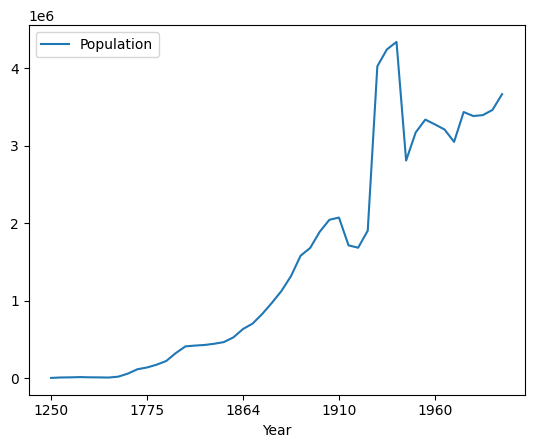

In [7]:
# concatenate all tables on population statistics
overall_population = pd.concat(berlin_population[2:5])
# extract the years
overall_population.Year = overall_population.Year.str.extract('(\d{4})', expand=False)
# set the index to the year column, so plotting is nicer
overall_population = overall_population.set_index("Year")
overall_population.plot();

## Beautiful Soup for Web Scraping

- HTML pages are often not well structured
- [Beautiful Soup](https://www.crummy.com/software/BeautifulSoup/)
    - tidies up dirty HTML
    - allows for convenient parsing of HTML


### A Simple Webpage



In [8]:
a_simple_webpage = \
"""<html>
    <head>
    </head>
    <body>
        <p>
            A paragraph
        </p>
        <p id="second_paragraph">
           Another paragraph with a <a href="https://de.wikipedia.org/wiki/Beuth_(Lokomotive)">link</a>
        </p>
    </body>
</html>"""

In [9]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(a_simple_webpage, 'html.parser')

In [10]:
list(soup.children)


[<html>
 <head>
 </head>
 <body>
 <p>
             A paragraph
         </p>
 <p id="second_paragraph">
            Another paragraph with a <a href="https://de.wikipedia.org/wiki/Beuth_(Lokomotive)">link</a>
 </p>
 </body>
 </html>]

## DOM Elements

![HTML DOM Model](figures/DOM-model.png)

### Extracting Texts

In [11]:
paragraphs = soup.find_all('p')
paragraphs

[<p>
             A paragraph
         </p>,
 <p id="second_paragraph">
            Another paragraph with a <a href="https://de.wikipedia.org/wiki/Beuth_(Lokomotive)">link</a>
 </p>]

In [12]:
[p.get_text().strip() for p in paragraphs]

['A paragraph', 'Another paragraph with a link']

### Extracting Links

In [13]:
links = soup.find_all('a')
links

[<a href="https://de.wikipedia.org/wiki/Beuth_(Lokomotive)">link</a>]

In [14]:
links[0].get('href')

'https://de.wikipedia.org/wiki/Beuth_(Lokomotive)'

### Extracting Arbitrary Elements

In [15]:
[x.get_text().strip() for x in soup.find_all(id="second_paragraph")]

['Another paragraph with a link']

## Example: Downloading Some Data from Wikipedia

Let's find out what was going on with [Christian Peter Beuth](https://de.wikipedia.org/wiki/Peter_Beuth_(Ministerialbeamter)) and [August Borsig](https://de.wikipedia.org/wiki/August_Borsig), or: Why is a steam locomotive and your university named after Beuth? 

In [16]:
import requests # for downloading web pages

url = "https://de.wikipedia.org/wiki/Beuth_(Lokomotive)"

page = requests.get(url)

### Excursion: HTML Status Codes
 
| Code | Type | Meaning |
|------|------|---------|
|1xx | Informational | The request was received, continuing process|
|2xx |Successful | The request was successfully received, understood, and accepted|
|3xx |Redirection| Further action needs to be taken in order to complete the request|
|4xx |Client Error| The request contains bad syntax or cannot be fulfilled|
|5xx |Server Error| The server failed to fulfill an apparently valid request|

In [17]:
page.content[:500]

b'<!DOCTYPE html>\n<html class="client-nojs" lang="de" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Beuth (Lokomotive) \xe2\x80\x93 Wikipedia</title>\n<script>document.documentElement.className="client-js";RLCONF={"wgBreakFrames":false,"wgSeparatorTransformTable":[",\\t.",".\\t,"],"wgDigitTransformTable":["",""],"wgDefaultDateFormat":"dmy","wgMonthNames":["","Januar","Februar","M\xc3\xa4rz","April","Mai","Juni","Juli","August","September","Oktober","November","Dezember"],"wgRequestId":"fa97c430-acb0-4fa6-94dd-c02'

In [18]:
# let beautiful soup parse the html
soup = BeautifulSoup(page.content, 'html.parser')
# find a paragraph in which both beuth (the person, not the steam locomotive) and borsig are mentioned
for p in soup.find_all('p'):
    if 'christian peter wilhelm beuth' in p.get_text().lower() \
        and 'borsig' in p.get_text().lower():
        print(p.get_text())

Die von August Borsig 1844 konstruierte Lokomotive BEUTH mit Werknummer 24 gilt als die erste eigenständig in Deutschland entwickelte Dampflokomotive. Vorher baute Borsig Lokomotiven nach amerikanischen Vorbildern nach. Die Lok gewann ein Wettrennen gegen ein Modell von Stephenson mit etwa zehn Minuten Vorsprung und galt für die folgenden zehn Jahre als Prototyp schneller deutscher Lokomotivkonstruktionen. Eine angetriebene Achse und zwei Laufachsen sowie ein Stehkessel sorgten für vergleichsweise hohe Geschwindigkeiten. Sie bekam ihren Namen nach dem Leiter der preußischen Gewerbeakademie Christian Peter Wilhelm Beuth, der August Borsig prophezeit hatte, dass aus ihm nie etwas werden würde. Ein Nachbau der Lok ist heute im Deutschen Technikmuseum Berlin ausgestellt.



## Crawling Data from Web Pages

- Beautiful Soup is great for extracting information from *single webpages*
- Often web sites have multiple pages
- Writing a custom 'spider' to crawl those websites can be tedious
- Dedicated libraries like [``scrapy``](https://doc.scrapy.org) help to scrape data from larger websites efficiently


## Legal Aspects of Scraping

Short version:

If you're doing it for research and if you're not circumventing technical barriers, it's ok. 

See https://www.forschung-und-lehre.de/recht/grenzen-des-web-scrapings-2421

## National vs International Legislation

- The internet is global / international
- Legislation / courts are national
- I will focus on **German Legislation** here

## Database Producer Right

The compilation of data served by website providers is protected by *Database Producer Right*

*Database Producers* (shopping portals, rating portals, …) have exclusive right to:
- Reproduce
- Distribute
- Publicly display

their data

## Implications

Usually web scraping is legal:
(Even if website usage conditions state that it’s not)

* If only minor parts of a DB are downloaded
* BGH (highest German court) decided 10% of a DB are minor
* If technical barriers are not circumvented

## Implications for Researchers

For non-commercial research: 
* ‘Copyright science barrier’:
* 75% of a DB can be downloaded
* But not distributed! 

Since 2018 ‘Barrier for Text und Data Mining (TDM)’
* Researchers can download entire DB to build corpus
* Must not be distributed
* Must be deleted after research project
* Source must be published

## Getting Data From REST APIs

[Representational State Transfer (REST)](https://en.wikipedia.org/wiki/Representational_state_transfer) is a software architectural style for creating web services

RESTful web services allow to access and manipulate web resources through a uniform and predefined set of stateless operations

## Example: Air Quality Data from AQICN

- Air quality is an important topic
- You can query recent worldwide air quality data through an API at [http://aqicn.org/](http://aqicn.org/)
- For example: 
    - [Air Quality Data Berlin](https://aqicn.org/city/germany/berlin)
    - For accessing the API, get an access token
    - then you can query the data for Berlin by requesting (in a browser or in a programmatic fashion)
        ``http://api.waqi.info/feed/berlin/?token=[accessToken]``
    - e.g. [http://api.waqi.info/feed/berlin/?token=my_access_token](http://api.waqi.info/feed/berlin/?token=7672327f1d6675ef5d2d554b63b6175afec9fe77)




In [21]:
import requests

# PLEASE USE YOUR OWN ACCESS TOKEN!
def get_air_quality_data(city, accesstoken='7672327f1d6675ef5d2d554b63b6175afec9fe77'):
    # build request
    url = 'http://api.waqi.info/feed/'+city+'/?token=' + accesstoken
    # get data
    r = requests.get(url, auth=('user', 'pass'))
    # check status code and return data
    if r.status_code == 200:
        data = r.json()
        return data['data']

get_air_quality_data('berlin')

{'aqi': 55,
 'idx': 6132,
 'attributions': [{'url': 'http://www.stadtentwicklung.berlin.de/umwelt/luftqualitaet/',
   'name': 'Berlin Air Quality - (Luftqualität in Berlin)',
   'logo': 'Germany-Berlin.png'},
  {'url': 'http://www.eea.europa.eu/themes/air/',
   'name': 'European Environment Agency',
   'logo': 'Europe-EEA.png'},
  {'url': 'https://waqi.info/', 'name': 'World Air Quality Index Project'}],
 'city': {'geo': [52.5200066, 13.404954],
  'name': 'Berlin, Germany',
  'url': 'https://aqicn.org/city/germany/berlin',
  'location': ''},
 'dominentpol': 'pm25',
 'iaqi': {'co': {'v': 0.1},
  'h': {'v': 90.4},
  'no2': {'v': 10.6},
  'o3': {'v': 12.2},
  'p': {'v': 999.6},
  'pm10': {'v': 16},
  'pm25': {'v': 55},
  't': {'v': 0},
  'w': {'v': 5.6}},
 'time': {'s': '2023-11-29 13:00:00',
  'tz': '+01:00',
  'v': 1701262800,
  'iso': '2023-11-29T13:00:00+01:00'},
 'forecast': {'daily': {'o3': [{'avg': 11,
     'day': '2023-11-27',
     'max': 18,
     'min': 2},
    {'avg': 16, 'day':

In [22]:
get_air_quality_data('newyork')

{'aqi': 34,
 'idx': 3309,
 'attributions': [{'url': 'http://www.dec.ny.gov/',
   'name': 'New York State Department of Environmental Conservation (NYSDEC)',
   'logo': 'US-NYDEC.png'},
  {'url': 'http://www.airnow.gov/', 'name': 'Air Now - US EPA'},
  {'url': 'https://waqi.info/', 'name': 'World Air Quality Index Project'}],
 'city': {'geo': [40.7127837, -74.0059413],
  'name': 'New York',
  'url': 'https://aqicn.org/city/newyork',
  'location': ''},
 'dominentpol': 'pm25',
 'iaqi': {'co': {'v': 4.5},
  'h': {'v': 60.1},
  'no2': {'v': 5.2},
  'o3': {'v': 19.2},
  'p': {'v': 1020.3},
  'pm25': {'v': 34},
  't': {'v': -1.4},
  'w': {'v': 0.4}},
 'time': {'s': '2023-11-29 08:00:00',
  'tz': '-05:00',
  'v': 1701244800,
  'iso': '2023-11-29T08:00:00-05:00'},
 'forecast': {'daily': {'o3': [{'avg': 6,
     'day': '2023-11-27',
     'max': 16,
     'min': 2},
    {'avg': 9, 'day': '2023-11-28', 'max': 13, 'min': 7},
    {'avg': 5, 'day': '2023-11-29', 'max': 11, 'min': 2},
    {'avg': 3, 'da

In [23]:
get_air_quality_data('seoul')

{'aqi': 53,
 'idx': 5508,
 'attributions': [{'url': 'https://www.airkorea.or.kr/',
   'name': 'South Air Korea Environment Corporation (대기오염실시간공개시스템)',
   'logo': 'SouthKorea-AirKorea.png'},
  {'url': 'http://cleanair.seoul.go.kr/',
   'name': 'Seoul Clean Air Pollution Information (서울특별시 기후대기환경정보)',
   'logo': 'SouthKorea-Seoul.png'},
  {'url': 'https://waqi.info/', 'name': 'World Air Quality Index Project'}],
 'city': {'geo': [37.566535, 126.9779692],
  'name': 'Seoul (서울)',
  'url': 'https://aqicn.org/city/seoul',
  'location': ''},
 'dominentpol': 'pm25',
 'iaqi': {'co': {'v': 5.2},
  'h': {'v': 62.4},
  'no2': {'v': 11.6},
  'o3': {'v': 26.6},
  'p': {'v': 1028.3},
  'pm10': {'v': 21},
  'pm25': {'v': 53},
  'r': {'v': 99},
  'so2': {'v': 4.6},
  't': {'v': -2.5},
  'w': {'v': 5.9},
  'wd': {'v': 292.5}},
 'time': {'s': '2023-11-29 22:00:00',
  'tz': '+09:00',
  'v': 1701295200,
  'iso': '2023-11-29T22:00:00+09:00'},
 'forecast': {'daily': {'o3': [{'avg': 1,
     'day': '2023-11-2

## Building your own REST API with ``flask``

- [``flask``](http://flask.pocoo.org/) is a microframework for web development in python
- We will build a simple REST API with flask


In [24]:
#!pip install newspaper3k
#!pip install Flask

In [1]:
import newspaper, json
newspapers = {  
    'zeit': 'http://zeit.de', 
    'tagesspiegel': 'https://www.tagesspiegel.de/'
}

def process_article(article):
    try:
        article.download()
        article.parse()
        return {
                'title': article.title,
                'url': article.url,
        }
    except: 
        pass
    
def process_newspaper(newspaper_url):
    articles = newspaper.build(newspaper_url).articles
    return [process_article(a) for a in articles]

def download_and_save_news(save_path='news.json'):
    news = {n:process_newspaper(url) for n,url in newspapers.items()}
    json.dump(news, open(save_path, 'wt'))

# download_and_save_news()

In [2]:
news = json.load(open('news.json'))
news

{'zeit': [{'title': 'Nachrichten, Hintergründe und Debatten',
   'url': 'http://zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/was-waere-wenn-die-europaeische-union-sich-aufloeste?utm_source=zeit&utm_medium=parkett\n      '},
  {'title': 'Nachrichten, Hintergründe und Debatten',
   'url': 'http://zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/food-start-ups-was-mit-essen?utm_source=zeit&utm_medium=parkett\n      '},
  {'title': 'Nachrichten, Hintergründe und Debatten',
   'url': 'http://www.zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/was-waere-wenn-die-europaeische-union-sich-aufloeste?utm_source=zeit&utm_medium=parkett\n      '},
  {'title': 'Nachrichten, Hintergründe und Debatten',
   'url': 'http://www.zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/food-start-ups-was-mit-esse

## A Minimal Flask API

in ``newsapi.py``:

```python

from flask import Flask, jsonify
import json

app = Flask(__name__)

### API

@app.route('/newsapi/<newspaper_id>')
def get_news_by_newspaper(newspaper_id):
    # return the news of a newspaper
    return jsonify(news.get(newspaper_id, {}))

if __name__ == "__main__":
    port = 5001
    # load some previously downloaded news 
    news = json.load(open('news.json'))
    app.run(host='0.0.0.0', port = port)

```

Now start the server by typing in the commandline

```
python newsapi.py
```

Opening a browser and navigating to ```http://0.0.0.0:5001/newsapi/zeit``` will yield
```
[{"title":"Nachrichten, Hintergr\u00fcnde und Debatten","url":"http://zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/was-waere-wenn-die-europaeische-union-sich-aufloeste?utm_source=zeit&utm_medium=parkett\n      "},{"title":"Nachrichten, Hintergr\u00fcnde und Debatten","url":"http://zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/food-start-ups-was-mit-essen?utm_source=zeit&utm_medium=parkett\n      "},{"title":"Nachrichten, Hintergr\u00fcnde und Debatten","url":"http://www.zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/was-waere-wenn-die-europaeische-union-sich-aufloeste?utm_source=zeit&utm_medium=parkett\n      "},{"title":"Nachrichten, Hintergr\u00fcnde und Debatten","url":"http://www.zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/food-start-ups-was-mit-essen?utm_source=zeit&utm_medium=parkett\n      "},{"title":"Nachrichten, Hintergr\u00fcnde und Debatten","url":"https://www.zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/was-waere-wenn-die-europaeische-union-sich-aufloeste?utm_source=zeit&utm_medium=parkett\n      "},{"title":"Nachrichten, Hintergr\u00fcnde und Debatten","url":"https://www.zeit.de/\n        https:/www.brandeins.de/magazine/brand-eins-wirtschaftsmagazin/2018/lebensmittel/food-start-ups-was-mit-essen?utm_source=zeit&utm_medium=parkett\n      "}]```